In [22]:
import nltk
from nltk.corpus import twitter_samples
from nltk.stem import PorterStemmer
from nltk.corpus import stopwords 
import re
import matplotlib.pyplot as plt
import string
from nltk.tokenize import TweetTokenizer
import numpy as np

In [23]:
all_positive = twitter_samples.strings('positive_tweets.json')
all_negative = twitter_samples.strings('negative_tweets.json')

tweets = tweets = all_positive + all_negative
print(len(tweets))

10000


In [24]:
def preprocess(tweet):
    Stemmer = PorterStemmer()
    Stopword_english = stopwords.words('english')
    punctuation = string.punctuation 

    preprocess_tweet = []

    tweet = re.sub(r'\$\w*', '', tweet)
    tweet = re.sub(r'^RT[\s]+', '', tweet)
    tweet = re.sub(r'https?://[^\s\n\r]+', '', tweet)
    tweet = re.sub(r'#', '', tweet)

    tokenize = TweetTokenizer(preserve_case=False, strip_handles=True, reduce_len=True)
    tweet_tokenize = tokenize.tokenize(tweet)
    
    for word in tweet_tokenize:     
        if( word not in punctuation and word not in Stopword_english):
            word = Stemmer.stem(word)
            preprocess_tweet.append(word)

    return preprocess_tweet

# preprocess(all_positive[2277])

In [25]:
def build_frequency(tweet,labels):
    
    labeList = np.squeeze(labels).tolist()
    freq = {}
    for y ,tweet in zip(labeList,tweet):
        for word in preprocess(tweet):
            pair = (word,y)
            if pair in freq:
                freq[pair] += 1
            else:
                freq[pair] = 1
    return freq

In [26]:
labels = np.append(np.ones(len(all_positive)),np.zeros(len(all_negative)))
len(labels)

10000

In [27]:
freq = build_frequency(tweets,labels)

In [28]:
freq

{('followfriday', 1.0): 25,
 ('top', 1.0): 32,
 ('engag', 1.0): 7,
 ('member', 1.0): 16,
 ('commun', 1.0): 33,
 ('week', 1.0): 83,
 (':)', 1.0): 3691,
 ('hey', 1.0): 77,
 ('jame', 1.0): 7,
 ('odd', 1.0): 2,
 (':/', 1.0): 5,
 ('pleas', 1.0): 99,
 ('call', 1.0): 37,
 ('contact', 1.0): 7,
 ('centr', 1.0): 2,
 ('02392441234', 1.0): 1,
 ('abl', 1.0): 8,
 ('assist', 1.0): 1,
 ('mani', 1.0): 33,
 ('thank', 1.0): 643,
 ('listen', 1.0): 17,
 ('last', 1.0): 47,
 ('night', 1.0): 68,
 ('bleed', 1.0): 2,
 ('amaz', 1.0): 51,
 ('track', 1.0): 5,
 ('scotland', 1.0): 2,
 ('congrat', 1.0): 21,
 ('yeaaah', 1.0): 1,
 ('yipppi', 1.0): 1,
 ('accnt', 1.0): 2,
 ('verifi', 1.0): 2,
 ('rqst', 1.0): 1,
 ('succeed', 1.0): 1,
 ('got', 1.0): 69,
 ('blue', 1.0): 9,
 ('tick', 1.0): 1,
 ('mark', 1.0): 1,
 ('fb', 1.0): 6,
 ('profil', 1.0): 2,
 ('15', 1.0): 5,
 ('day', 1.0): 246,
 ('one', 1.0): 131,
 ('irresist', 1.0): 2,
 ('flipkartfashionfriday', 1.0): 17,
 ('like', 1.0): 233,
 ('keep', 1.0): 68,
 ('love', 1.0): 401,


In [29]:
keys = ['happi', 'merri', 'nice', 'good', 'bad', 'sad', 'mad', 'best', 'pretti']

data=[]

for words in keys:
    pos = 0
    neg = 0

    if((words,1) in freq):
        pos = freq[(words,1)]
    if((words,0)in freq):
        neg = freq[(words,0)]

    data.append([words,pos,neg])
data

[['happi', 212, 25],
 ['merri', 1, 0],
 ['nice', 99, 19],
 ['good', 238, 101],
 ['bad', 18, 73],
 ['sad', 5, 123],
 ['mad', 4, 11],
 ['best', 65, 22],
 ['pretti', 20, 15]]

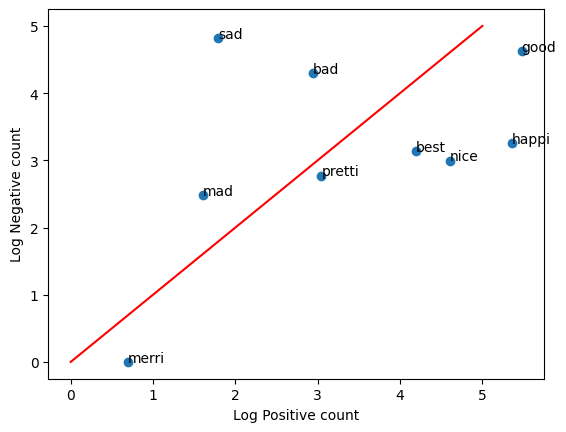

In [37]:
X = np.log([x[1]+1 for x in data])
Y = np.log([x[2]+1 for x in data])

plt.scatter(X,Y)
plt.plot([0,5],[0,5],c="Red")

plt.xlabel("Log Positive count")
plt.ylabel("Log Negative count")

for i in range(0,len(data)):
    plt.annotate(data[i][0],(X[i],Y[i]))